# Machine Learning — Notebook 12
## Cross-Validation y Hyperparameter Tuning (Regresión)

**Dataset:** Wine (sklearn) — predecir `proline` (mg/L) a partir de 12 propiedades químicas.

| Técnica | Idea central | Cuándo usarla |
|---|---|---|
| **Cross-Validation** | Estimar el error real rotando el conjunto de validación | Siempre, antes de reportar métricas |
| **RandomSearchCV** | Evaluar combinaciones aleatorias del espacio de hiperparámetros | Espacios grandes, presupuesto limitado |
| **GridSearchCV** | Evaluar *todas* las combinaciones posibles | Espacios pequeños, búsqueda exhaustiva |
| **Optuna** | Búsqueda bayesiana — aprende qué zonas explorar | Espacios muy grandes, máxima eficiencia |

> Todo el notebook usa `RandomForestRegressor` como modelo base.

In [1]:
!pip3 install optuna --quiet --break-system-packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (KFold, cross_val_score, cross_validate,
                                      RandomizedSearchCV, GridSearchCV)
from sklearn.metrics import r2_score

RANDOM_STATE = 7

# Dataset: 178 vinos, 13 propiedades químicas
# Objetivo: predecir 'proline' (aminoácido) a partir de las otras 12
data = load_wine()
df   = pd.DataFrame(data.data, columns=data.feature_names)
X    = df.drop(columns=['proline'])
y    = df['proline']

print(f"Muestras : {X.shape[0]} | Features : {X.shape[1]}")
print(f"Target 'proline': min={y.min():.0f}  max={y.max():.0f}  media={y.mean():.0f} mg/L")
X.head(3)

Muestras : 178 | Features : 12
Target 'proline': min=278  max=1680  media=747 mg/L


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17


In [2]:
y

0      1065.0
1      1050.0
2      1185.0
3      1480.0
4       735.0
        ...  
173     740.0
174     750.0
175     835.0
176     840.0
177     560.0
Name: proline, Length: 178, dtype: float64

In [3]:
# ── CROSS-VALIDATION ─────────────────────────────────────────────────────────
# KFold: divide en k partes, entrena en k-1, evalúa en 1, rota k veces.
# El score final es la media — mucho más confiable que un solo train/test split.

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelo_base = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE))
])

# cross_val_score: una métrica
scores_r2 = cross_val_score(modelo_base, X, y, cv=cv, scoring='r2')
print(f"R² por fold : {np.round(scores_r2, 3)}")
print(f"R² medio    : {scores_r2.mean():.3f} ± {scores_r2.std():.3f}")

# cross_validate: varias métricas + score de entrenamiento
resultado = cross_validate(modelo_base, X, y, cv=cv,
                           scoring={'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'},
                           return_train_score=True)

print(f"\nTrain R²  : {resultado['train_r2'].mean():.3f}  "
      f"Val R²  : {resultado['test_r2'].mean():.3f}")
print(f"Train RMSE: {-resultado['train_rmse'].mean():.1f}  "
      f"Val RMSE: {-resultado['test_rmse'].mean():.1f} mg/L")

R² por fold : [0.644 0.546 0.698 0.619 0.728]
R² medio    : 0.647 ± 0.064

Train R²  : 0.959  Val R²  : 0.647
Train RMSE: 63.2  Val RMSE: 179.3 mg/L


In [4]:
# ── RANDOMSEARCHCV ───────────────────────────────────────────────────────────
# Muestrea n_iter combinaciones aleatorias del espacio de hiperparámetros.
# Mucho más eficiente que Grid cuando el espacio es grande.

espacio = {
    'rf__n_estimators':      [50, 100, 200, 300],
    'rf__max_depth':         [None, 5, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf':  [1, 2, 4],
    'rf__max_features':      ['sqrt', 'log2', 0.5],
}

random_search = RandomizedSearchCV(
    modelo_base, param_distributions=espacio,
    n_iter=30, cv=cv, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1
)
random_search.fit(X, y)

print(f"RandomSearch — Mejor R² (CV): {random_search.best_score_:.3f}")
print(f"Mejores parámetros: {random_search.best_params_}")

# GridSearchCV — exhaustivo: evalúa TODAS las combinaciones (más lento)
# grid_search = GridSearchCV(modelo_base, param_grid=espacio, cv=cv, scoring='r2', n_jobs=-1)
# grid_search.fit(X, y)
# print(f"GridSearch — Mejor R²: {grid_search.best_score_:.3f}")

RandomSearch — Mejor R² (CV): 0.685
Mejores parámetros: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'log2', 'rf__max_depth': 10}


---
## Búsqueda Bayesiana con Optuna

Optuna construye un modelo probabilístico del espacio de hiperparámetros y **dirige la búsqueda** hacia las zonas más prometedoras (algoritmo TPE — Tree-structured Parzen Estimator).  
Con el mismo número de evaluaciones, generalmente supera a RandomSearch.

https://optuna.org

**Optuna** 
- es un framework de código abierto en Python diseñado para la optimización automática de hiperparámetros en modelos de machine learning y deep learning.
- Destaca por su API "definida por ejecución", que permite construir espacios de búsqueda dinámicos. Utiliza algoritmos avanzados como la optimización bayesiana (TPE) para encontrar configuraciones óptimas eficientemente.
- Características Clave:
    - Eficiencia: Algoritmos de vanguardia (TPE, CMA-ES) para búsqueda rápida, incluyendo la poda (pruning) de ensayos poco prometedores.
    - Flexibilidad: API estilo "define-by-run", permitiendo definir espacios de búsqueda con condicionales y bucles de Python.
    - Paralelización: Soporte para paralelizar búsquedas en múltiples procesos o hilos sin alterar la estructura del código.
    - Integración: Compatible con los principales frameworks como PyTorch, TensorFlow, Scikit-learn, XGBoost, entre otros.
    - Visualización: Herramientas integradas para visualizar la importancia de los hiperparámetros y el progreso de la optimización.

**Conceptos Básicos**:
- Study (Estudio): Un conjunto de ensayos orientados a optimizar una función objetivo.
- Trial (Ensayo): Una única ejecución de la función objetivo, probando un conjunto de hiperparámetros.

Optuna, desarrollado por Preferred Networks, es ampliamente utilizado para mejorar el rendimiento de modelos al automatizar el tedioso proceso de sintonización manual.

![optuna](https://optuna.org/assets/img/optuna-v5-roadmap-blog.webp)

Optuna — Mejor R² (CV): 0.688
Mejores parámetros: {'n_estimators': 237, 'max_depth': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}


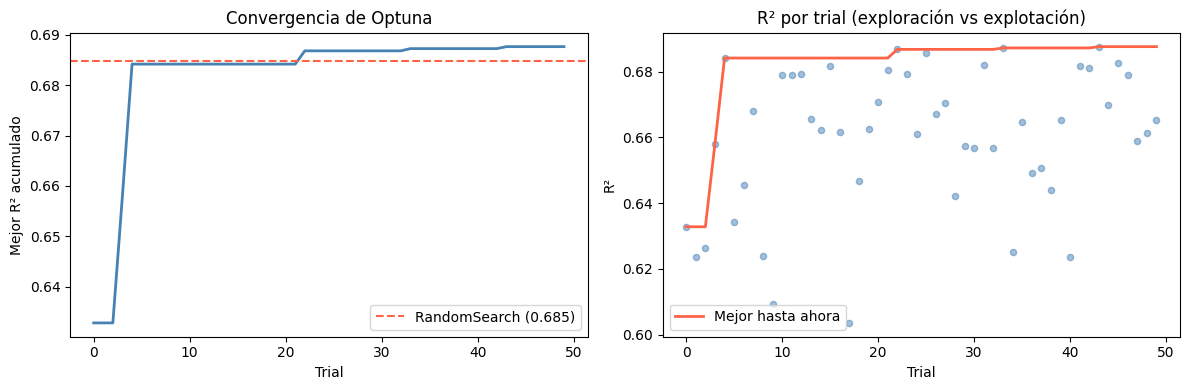

In [5]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 50, 400),
        max_depth         = trial.suggest_categorical('max_depth', [None, 5, 10, 20, 30]),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 15),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 8),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
    )
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestRegressor(**params, random_state=RANDOM_STATE))
    ])
    return cross_val_score(pipe, X, y, cv=cv, scoring='r2').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Optuna — Mejor R² (CV): {study.best_value:.3f}")
print(f"Mejores parámetros: {study.best_params}")

# Evolución del mejor R² por trial
valores = [t.value for t in study.trials]
mejores = np.maximum.accumulate(valores)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mejores, color='steelblue', linewidth=2)
axes[0].axhline(random_search.best_score_, linestyle='--', color='tomato',
                label=f'RandomSearch ({random_search.best_score_:.3f})')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Mejor R² acumulado')
axes[0].set_title('Convergencia de Optuna'); axes[0].legend()

axes[1].scatter(range(len(valores)), valores, alpha=0.5, s=20, color='steelblue')
axes[1].plot(mejores, color='tomato', linewidth=2, label='Mejor hasta ahora')
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('R²')
axes[1].set_title('R² por trial (exploración vs explotación)'); axes[1].legend()

plt.tight_layout()
plt.show()

---
## Resumen comparativo

                          R² CV        Evaluaciones       Estrategia
Método                                                              
Baseline (RF default)     0.647        5  (solo CV)          ninguna
RandomSearchCV (30 iter)  0.685  30 × 5 folds = 150        aleatoria
Optuna TPE (50 trials)    0.688  50 × 5 folds = 250  bayesiana (TPE)


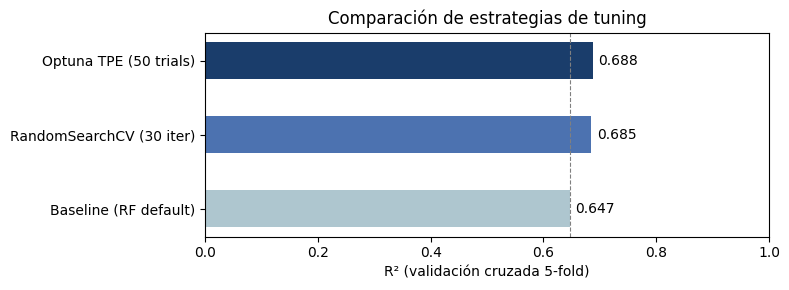

In [6]:
resumen = pd.DataFrame([
    {'Método':             'Baseline (RF default)',
     'R² CV':             round(scores_r2.mean(), 3),
     'Evaluaciones':      '5  (solo CV)',
     'Estrategia':        'ninguna'},
    {'Método':             'RandomSearchCV (30 iter)',
     'R² CV':             round(random_search.best_score_, 3),
     'Evaluaciones':      '30 × 5 folds = 150',
     'Estrategia':        'aleatoria'},
    {'Método':             'Optuna TPE (50 trials)',
     'R² CV':             round(study.best_value, 3),
     'Evaluaciones':      '50 × 5 folds = 250',
     'Estrategia':        'bayesiana (TPE)'},
]).set_index('Método')

print(resumen.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
colores = ['#aec6cf', '#4C72B0', '#1a3d6b']
bars = ax.barh(resumen.index, resumen['R² CV'], color=colores, height=0.5)
ax.bar_label(bars, fmt='%.3f', padding=4)
ax.set_xlim(0, 1)
ax.set_xlabel('R² (validación cruzada 5-fold)')
ax.set_title('Comparación de estrategias de tuning')
ax.axvline(scores_r2.mean(), linestyle='--', color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()